
# Clustering probabilístico: **Gaussian Mixture Models (GMM)**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal


## Datasets sintéticos

- **Blobs esféricos**: misma forma, ideal para comparar K-Means y GMM en su caso "fácil"
- **Blobs elípticos/anisotrópicos**: distinta orientación y varianza por cluster, donde K-Means falla y GMM no
- **Blobs solapados**: clusters que se traslapan, para ver clustering hard vs soft


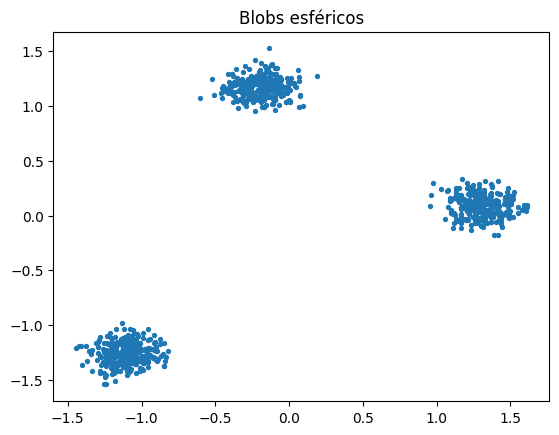

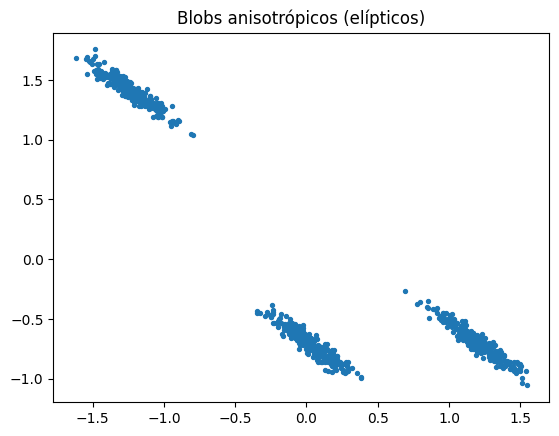

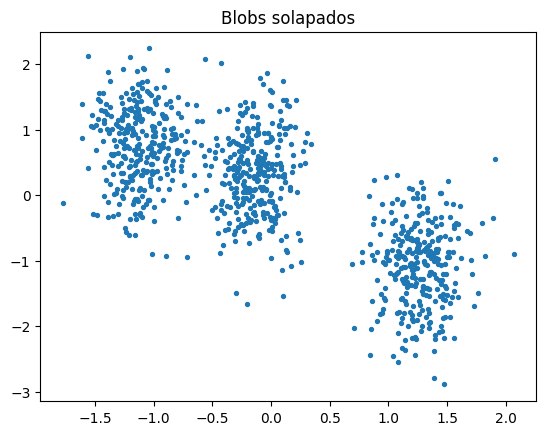

In [2]:
X_blobs, y_blobs = make_blobs(n_samples=900, centers=3, cluster_std=0.60, random_state=42)

# Estiramos y rotamos los blobs para que tengan covarianzas distintas (anisotropía)
rng = np.random.RandomState(42)
transformation = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_aniso = np.dot(X_blobs, transformation)

X_overlap, y_overlap = make_blobs(n_samples=900, centers=3, cluster_std=1.6, random_state=7)

scaler = StandardScaler()
X_blobs_s = scaler.fit_transform(X_blobs)
X_aniso_s = scaler.fit_transform(X_aniso)
X_overlap_s = scaler.fit_transform(X_overlap)

fig = plt.figure()
plt.scatter(X_blobs_s[:,0], X_blobs_s[:,1], s=8)
plt.title("Blobs esféricos")
plt.show()

fig = plt.figure()
plt.scatter(X_aniso_s[:,0], X_aniso_s[:,1], s=8)
plt.title("Blobs anisotrópicos (elípticos)")
plt.show()

fig = plt.figure()
plt.scatter(X_overlap_s[:,0], X_overlap_s[:,1], s=8)
plt.title("Blobs solapados")
plt.show()


## K-Means vs GMM en blobs anisotrópicos

Con blobs esféricos, K-Means y GMM dan resultados muy parecidos. El caso interesante es cuando los
clusters tienen **formas elípticas y orientaciones distintas**: K-Means asume clusters esféricos
(distancia euclidiana al centroide), mientras que GMM puede modelar covarianzas arbitrarias.


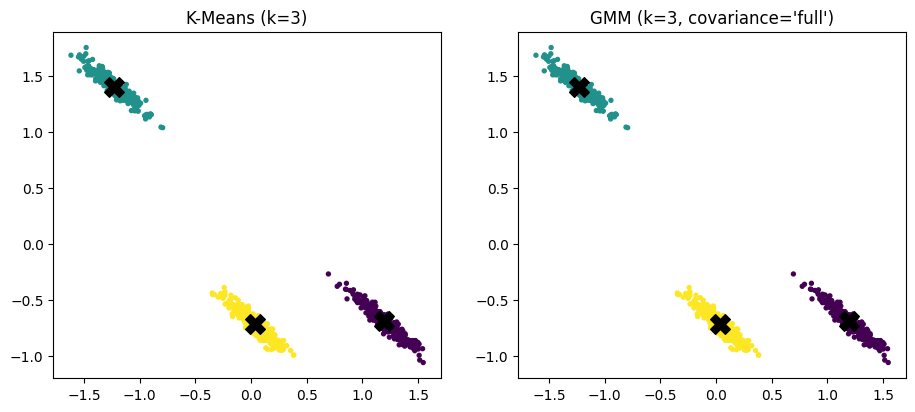

In [3]:
k = 3

km = KMeans(n_clusters=k, n_init=10, random_state=42)
labels_km = km.fit_predict(X_aniso_s)

gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
labels_gmm = gmm.fit_predict(X_aniso_s)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X_aniso_s[:,0], X_aniso_s[:,1], s=8, c=labels_km)
axes[0].scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], marker='X', s=200, c='black')
axes[0].set_title("K-Means (k=3)")

axes[1].scatter(X_aniso_s[:,0], X_aniso_s[:,1], s=8, c=labels_gmm)
axes[1].scatter(gmm.means_[:,0], gmm.means_[:,1], marker='X', s=200, c='black')
axes[1].set_title("GMM (k=3, covariance='full')")
plt.show()


### Visualizando las elipses de covarianza aprendidas por GMM

Cada componente gaussiano queda descrito por su media $\mu_k$ y su matriz de covarianza $\Sigma_k$.
Podemos dibujar la elipse de 2 desviaciones estándar de cada componente para ver qué aprendió el modelo.


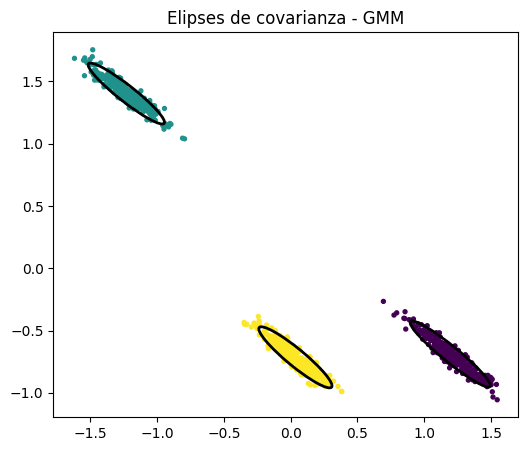

In [4]:
from matplotlib.patches import Ellipse

def plot_gmm_ellipses(X, gmm, labels, ax=None, title=""):
    if ax is None:
        fig, ax = plt.subplots()
    ax.scatter(X[:,0], X[:,1], s=8, c=labels, zorder=1)
    for mean, cov in zip(gmm.means_, gmm.covariances_):
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
        width, height = 2 * 2 * np.sqrt(vals)  # 2 sigma
        ell = Ellipse(mean, width, height, angle=angle, edgecolor='black',
                      facecolor='none', linewidth=2, zorder=2)
        ax.add_patch(ell)
    ax.set_title(title)
    return ax

fig, ax = plt.subplots(figsize=(6,5))
plot_gmm_ellipses(X_aniso_s, gmm, labels_gmm, ax=ax, title="Elipses de covarianza - GMM")
plt.show()


## Clustering duro vs. clustering suave

GMM no solo entrega una etiqueta por punto (`predict`), también entrega la **probabilidad de
pertenencia** a cada componente (`predict_proba`), es decir los $\gamma_{ik}$.

Vamos a visualizar la incertidumbre: los puntos cerca del "borde" entre dos clusters tendrán
probabilidades repartidas, mientras que los puntos "típicos" de un cluster tendrán probabilidad
cercana a 1 en su componente dominante.


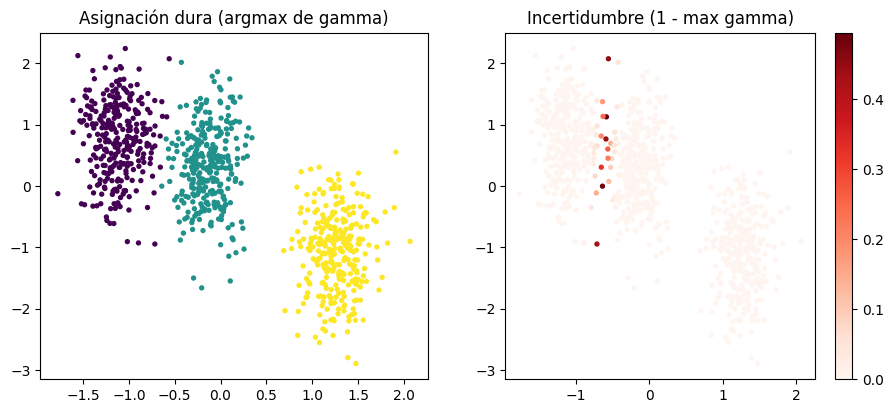

Ejemplo de responsabilidades (gamma) para los primeros 5 puntos:
[[0.    1.    0.   ]
 [0.997 0.003 0.   ]
 [1.    0.    0.   ]
 [0.    0.    1.   ]
 [0.    0.    1.   ]]


In [5]:
gmm_overlap = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
labels_overlap = gmm_overlap.fit_predict(X_overlap_s)
proba_overlap = gmm_overlap.predict_proba(X_overlap_s)

# Incertidumbre = 1 - probabilidad máxima (qué tan lejos está de una asignación "segura")
max_proba = proba_overlap.max(axis=1)
uncertainty = 1 - max_proba

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X_overlap_s[:,0], X_overlap_s[:,1], s=8, c=labels_overlap)
axes[0].set_title("Asignación dura (argmax de gamma)")

sc = axes[1].scatter(X_overlap_s[:,0], X_overlap_s[:,1], s=8, c=uncertainty, cmap='Reds')
axes[1].set_title("Incertidumbre (1 - max gamma)")
plt.colorbar(sc, ax=axes[1])
plt.show()

print("Ejemplo de responsabilidades (gamma) para los primeros 5 puntos:")
print(np.round(proba_overlap[:5], 3))


## El algoritmo EM paso a paso (implementación manual, 1D)

Para conectar con la teoría: implementamos EM a mano para una mezcla de 2 gaussianas en 1D,
y graficamos cómo evoluciona la log-verosimilitud en cada iteración hasta converger.

- **E-step**: con los parámetros actuales, calculamos $\gamma_{ik} = P(k \mid x_i)$
- **M-step**: con esas responsabilidades, actualizamos $w_k$, $\mu_k$, $\sigma_k^2$


Pesos estimados: [0.401 0.599]
Medias estimadas: [ 2.998 -1.941]
Varianzas estimadas: [1.747 0.578]


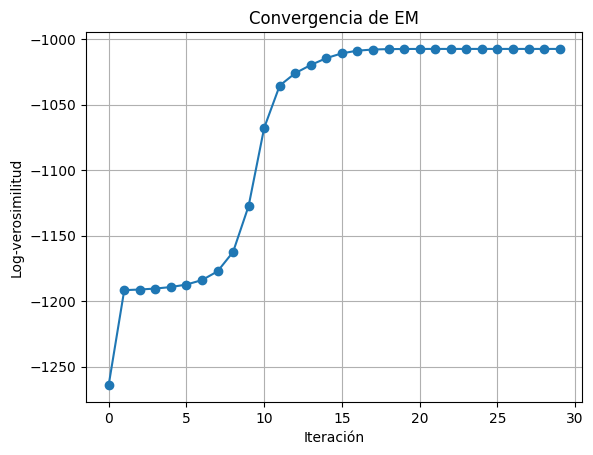

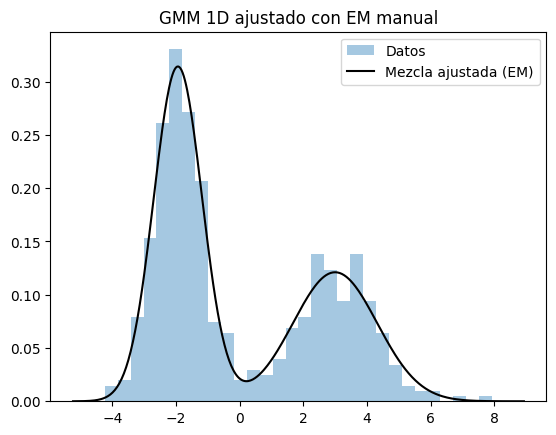

In [6]:
def em_gmm_1d(x, k=2, n_iter=30, seed=0):
    rng = np.random.RandomState(seed)
    n = len(x)

    # Inicialización
    w = np.full(k, 1.0 / k)
    mu = rng.choice(x, size=k, replace=False)
    var = np.full(k, np.var(x))

    log_likelihoods = []

    for it in range(n_iter):
        # E-step
        gamma = np.zeros((n, k))
        for j in range(k):
            gamma[:, j] = w[j] * (1.0 / np.sqrt(2*np.pi*var[j])) * np.exp(-0.5*(x-mu[j])**2/var[j])
        total = gamma.sum(axis=1, keepdims=True)
        log_likelihoods.append(np.sum(np.log(total)))
        gamma = gamma / total

        # M-step
        Nk = gamma.sum(axis=0)
        w = Nk / n
        mu = (gamma * x[:, None]).sum(axis=0) / Nk
        var = (gamma * (x[:, None] - mu[None, :])**2).sum(axis=0) / Nk

    return w, mu, var, log_likelihoods

# Datos sintéticos: mezcla de 2 gaussianas en 1D
x1 = np.random.RandomState(1).normal(-2, 0.8, 300)
x2 = np.random.RandomState(2).normal(3, 1.2, 200)
x = np.concatenate([x1, x2])

w, mu, var, log_likelihoods = em_gmm_1d(x, k=2, n_iter=30, seed=0)

print(f"Pesos estimados: {np.round(w, 3)}")
print(f"Medias estimadas: {np.round(mu, 3)}")
print(f"Varianzas estimadas: {np.round(var, 3)}")

fig = plt.figure()
plt.plot(log_likelihoods, marker='o')
plt.xlabel("Iteración")
plt.ylabel("Log-verosimilitud")
plt.title("Convergencia de EM")
plt.grid(True)
plt.show()

# Histograma + densidad de la mezcla ajustada
xs = np.linspace(x.min()-1, x.max()+1, 400)
density = sum(w[j]*(1/np.sqrt(2*np.pi*var[j]))*np.exp(-0.5*(xs-mu[j])**2/var[j]) for j in range(2))

fig = plt.figure()
plt.hist(x, bins=30, density=True, alpha=0.4, label="Datos")
plt.plot(xs, density, color='black', label="Mezcla ajustada (EM)")
plt.legend()
plt.title("GMM 1D ajustado con EM manual")
plt.show()


## ¿Cómo elegir K? BIC y AIC

A diferencia del método del codo en K-Means, para GMM se suele usar **BIC** (Bayesian Information
Criterion) o **AIC** (Akaike Information Criterion), que penalizan la log-verosimilitud por la
cantidad de parámetros del modelo. Buscamos el K que minimiza BIC/AIC.


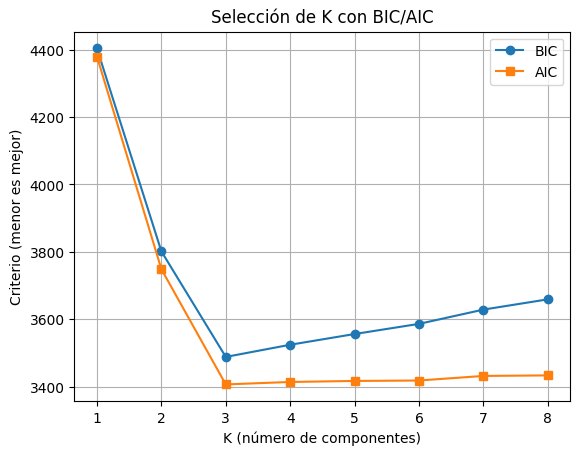

Mejor K según BIC: 3


In [7]:
k_range = range(1, 9)
bics, aics = [], []

for k in k_range:
    gmm_k = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=3)
    gmm_k.fit(X_overlap_s)
    bics.append(gmm_k.bic(X_overlap_s))
    aics.append(gmm_k.aic(X_overlap_s))

fig = plt.figure()
plt.plot(list(k_range), bics, marker='o', label='BIC')
plt.plot(list(k_range), aics, marker='s', label='AIC')
plt.xlabel("K (número de componentes)")
plt.ylabel("Criterio (menor es mejor)")
plt.title("Selección de K con BIC/AIC")
plt.legend()
plt.grid(True)
plt.show()

best_k_bic = list(k_range)[int(np.argmin(bics))]
print(f"Mejor K según BIC: {best_k_bic}")


## Tipos de covarianza en GaussianMixture

sklearn permite restringir la forma de $\Sigma_k$ mediante el parámetro `covariance_type`:

- **`spherical`**: cada componente es una esfera (varianza igual en todas las direcciones)
- **`diag`**: elipses alineadas a los ejes (sin correlación entre variables)
- **`tied`**: todos los componentes comparten la misma matriz de covarianza (misma forma/orientación)
- **`full`**: cada componente tiene su propia matriz de covarianza completa (más flexible, más parámetros)


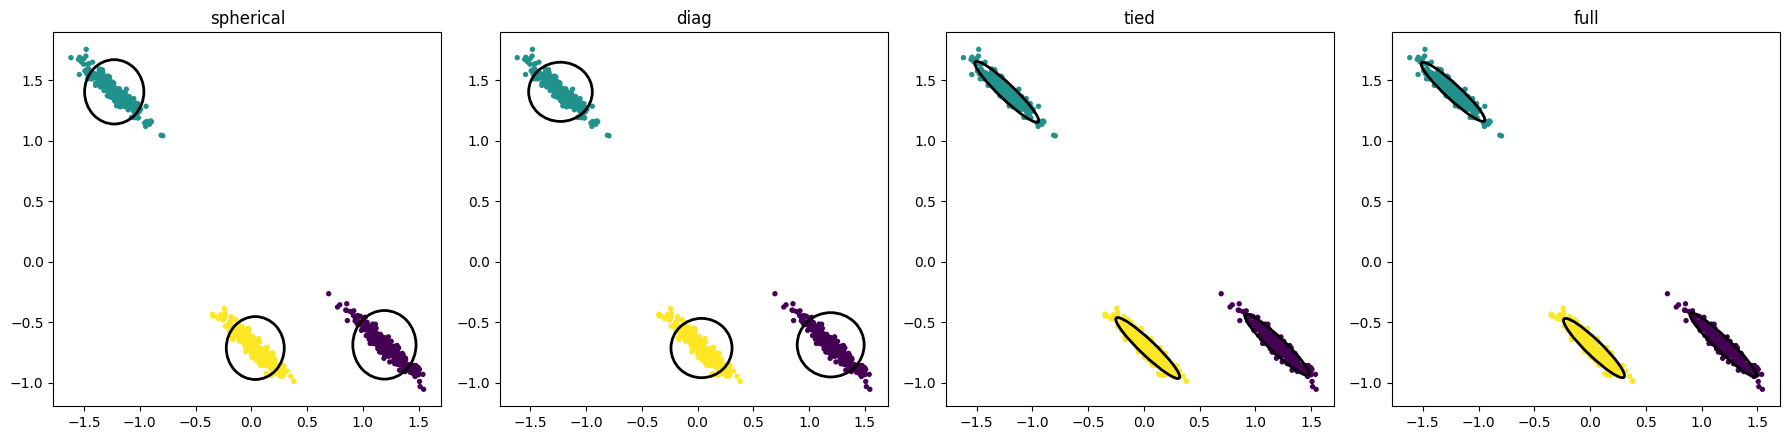

In [8]:
cov_types = ['spherical', 'diag', 'tied', 'full']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, cov_type in zip(axes, cov_types):
    gmm_c = GaussianMixture(n_components=3, covariance_type=cov_type, random_state=42)
    labels_c = gmm_c.fit_predict(X_aniso_s)

    covs = gmm_c.covariances_
    if cov_type == 'spherical':
        covs = np.array([np.eye(2)*c for c in covs])
    elif cov_type == 'diag':
        covs = np.array([np.diag(c) for c in covs])
    elif cov_type == 'tied':
        covs = np.array([covs for _ in range(3)])

    gmm_c.covariances_ = covs  # solo para reutilizar la función de graficar elipses
    plot_gmm_ellipses(X_aniso_s, gmm_c, labels_c, ax=ax, title=cov_type)

plt.tight_layout()
plt.show()

# Actividad

Vamos a aplicar **GMM** sobre 4 datasets sintéticos específicos: `X_blobs_4`, `X_aniso_5`, `X_overlap_5` y `X_moons_2`.

1. Para los primeros 3 datasets (`blobs`, `aniso`, `overlap`), use **BIC** para elegir el mejor `K` (pruebe de 1 a 8) y grafique la curva del BIC.
2. Con el mejor `K` encontrado, ajuste el GMM (`covariance_type='full'`) y grafique los clusters junto con las elipses de covarianza.
3. Compare, para `X_aniso_5`, los resultados de K-Means vs GMM. ¿Difieren?
4. Utilice GMM sobre el dataset de medias lunas (`X_moons_2`) y comente por qué no logra separar bien los clusters.
5. Cuando terminen, avisen para marcarlo como logrado.

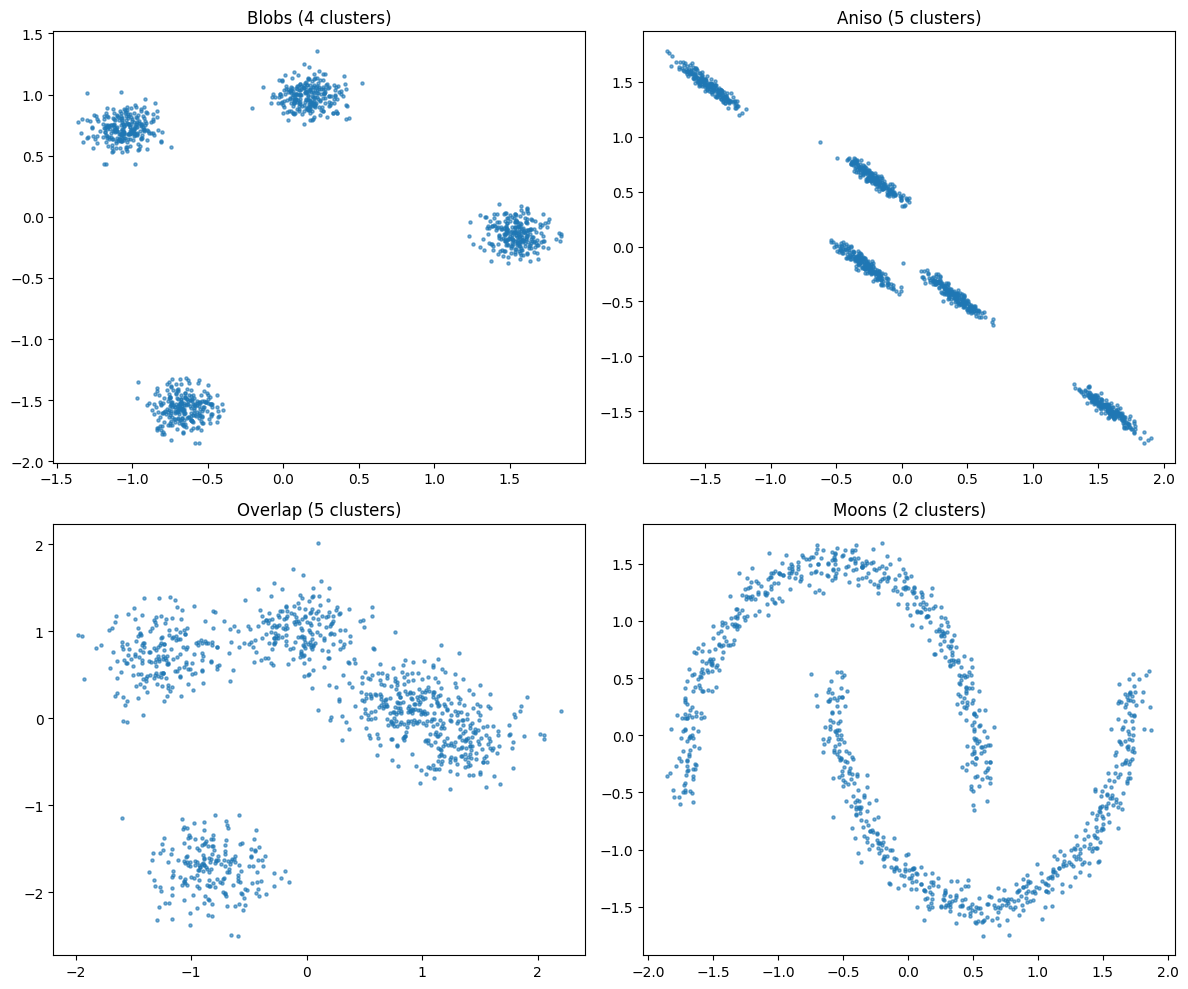

In [9]:
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. Blobs 4 clusters
X_blobs_4, _ = make_blobs(n_samples=1000, centers=4, cluster_std=0.60, random_state=42)

# 2. Aniso 5 clusters
X_base_5, _ = make_blobs(n_samples=1000, centers=5, cluster_std=0.70, random_state=10)
transformation = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_aniso_5 = np.dot(X_base_5, transformation)

# 3. Overlap 5 clusters
X_overlap_5, _ = make_blobs(n_samples=1000, centers=5, cluster_std=1.5, random_state=42)

# 4. Moons 2 clusters
X_moons_2, _ = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Escalado
scaler = StandardScaler()
X_blobs_4 = scaler.fit_transform(X_blobs_4)
X_aniso_5 = scaler.fit_transform(X_aniso_5)
X_overlap_5 = scaler.fit_transform(X_overlap_5)
X_moons_2 = scaler.fit_transform(X_moons_2)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].scatter(X_blobs_4[:, 0], X_blobs_4[:, 1], s=5, alpha=0.6)
axes[0, 0].set_title("Blobs (4 clusters)")

axes[0, 1].scatter(X_aniso_5[:, 0], X_aniso_5[:, 1], s=5, alpha=0.6)
axes[0, 1].set_title("Aniso (5 clusters)")

axes[1, 0].scatter(X_overlap_5[:, 0], X_overlap_5[:, 1], s=5, alpha=0.6)
axes[1, 0].set_title("Overlap (5 clusters)")

axes[1, 1].scatter(X_moons_2[:, 0], X_moons_2[:, 1], s=5, alpha=0.6)
axes[1, 1].set_title("Moons (2 clusters)")

plt.tight_layout()
plt.show()